# Credit Scoring Model

### Life Cycle of Machine Learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to Perform
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Model Training
- Model Evaluation
- Model Deployment

# 1) Problem Statement

This project predicts whether a customer is a good or bad credit risk using financial information such as income, debt ratio, payment history, and credit utilization.

# 2) Data Collection


- Dataset Source:
  https://www.kaggle.com/c/GiveMeSomeCredit/data

- The dataset contains financial details of customers and their loan repayment behavior.

# 2.1 Import Data and Required Packages


importing pandas, numpy, matplotlib, seaborn and Warnigs library

In [52]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [53]:
df = pd.read_csv("credit_data.csv")

In [54]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [55]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [56]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [57]:
print("Data shape:", df.shape)

Data shape: (150000, 11)


In [58]:
print("Missing value:\n",df.isnull().sum())

Missing value:
 SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


Handle Missing values

1. MonthlyIncome: Impute with median                           

In [59]:
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)

2. NumberOfDependents: Impute with 0(or median)

In [60]:
df['NumberOfDependents'].fillna(0, inplace=True)

In [61]:
print('Missing value after imputation:\n', df.isnull().sum())

Missing value after imputation:
 SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [62]:
print("Cheak Duplicates:", df.duplicated().sum())

Cheak Duplicates: 767


In [63]:
print("Shape before removing duplicates:", df.shape)

Shape before removing duplicates: (150000, 11)


In [64]:
df.drop_duplicates(inplace=True)

In [65]:
print("Shape before after duplicates:", df.shape)

Shape before after duplicates: (149233, 11)


In [66]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


Cheak data types 

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149233 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149233 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149233 non-null  float64
 2   age                                   149233 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149233 non-null  int64  
 4   DebtRatio                             149233 non-null  float64
 5   MonthlyIncome                         149233 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149233 non-null  int64  
 7   NumberOfTimes90DaysLate               149233 non-null  int64  
 8   NumberRealEstateLoansOrLines          149233 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149233 non-null  int64  
 10  NumberOfDependents                    149233 non-null  float64
dtypes: fl

Cheaking the number of unique values of each columns

In [70]:
df.nunique()

SeriousDlqin2yrs                             2
RevolvingUtilizationOfUnsecuredLines    125728
age                                         86
NumberOfTime30-59DaysPastDueNotWorse        16
DebtRatio                               114194
MonthlyIncome                            13594
NumberOfOpenCreditLinesAndLoans             58
NumberOfTimes90DaysLate                     19
NumberRealEstateLoansOrLines                28
NumberOfTime60-89DaysPastDueNotWorse        13
NumberOfDependents                          13
dtype: int64

Cheaking Statistics of data set

In [72]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149233.000000,149233.000000,149233.000000,149233.000000,149233.000000,1.492330e+05,149233.000000,149233.000000,149233.000000,149233.000000,149233.000000
mean,0.067036,6.077045,52.298145,0.388386,354.808254,6.426774e+03,8.488082,0.232435,1.023473,0.206811,0.741177
std,0.250085,250.396053,14.714050,3.779712,2042.891693,1.292246e+04,5.134233,3.752133,1.130304,3.736132,1.108596
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030210,41.000000,0.000000,0.178098,3.900000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154285,52.000000,0.000000,0.368578,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.555959,63.000000,0.000000,0.877090,7.409000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Cheaking Target Distribution

In [75]:
target_dist = df['SeriousDlqin2yrs'].value_counts(normalize=True)
print(f"Traget distribution: {target_dist}")

Traget distribution: SeriousDlqin2yrs
0    0.932964
1    0.067036
Name: proportion, dtype: float64


Plot Target Distribution

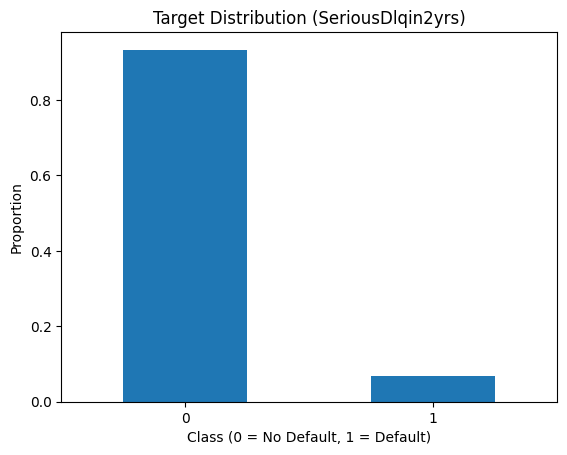

In [77]:
plt.figure()
target_dist.plot(kind='bar')

plt.title('Target Distribution (SeriousDlqin2yrs)')
plt.xlabel('Class (0 = No Default, 1 = Default)')
plt.ylabel('Proportion')

plt.xticks(rotation=0)
plt.show()

Outlier Detect

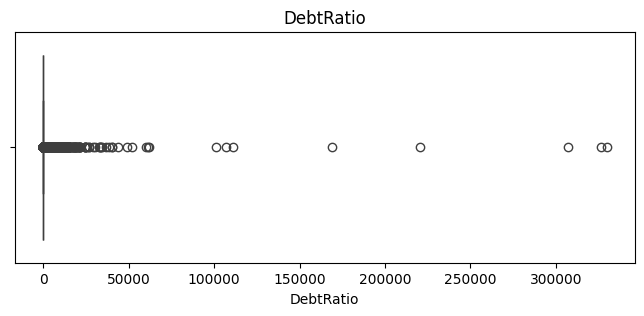

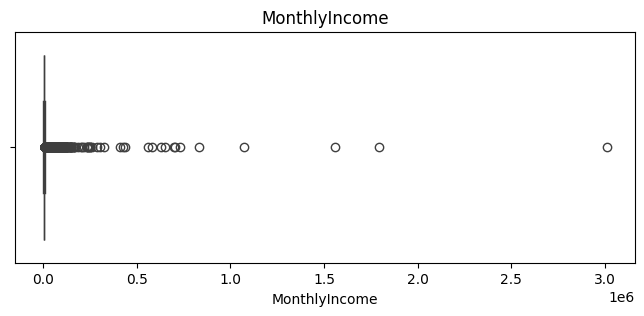

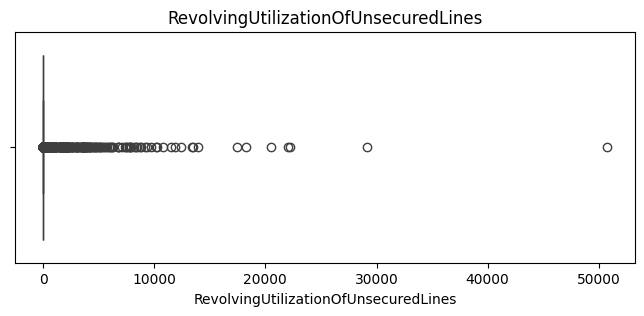

In [80]:
for col in ['DebtRatio','MonthlyIncome','RevolvingUtilizationOfUnsecuredLines']:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Insight

- DebtRatio contains extreme outliers.
- MonthlyIncome is highly right-skewed.
- RevolvingUtilizationOfUnsecuredLines has unusually large values.
- Outliers may carry useful risk information, so they were retained initially.

# Skewness Check

In [81]:
df.skew(numeric_only=True).sort_values(ascending=False)

MonthlyIncome                           126.824369
RevolvingUtilizationOfUnsecuredLines     97.381681
DebtRatio                                94.933456
NumberOfTime60-89DaysPastDueNotWorse     25.925295
NumberOfTimes90DaysLate                  25.589031
NumberOfTime30-59DaysPastDueNotWorse     24.918361
NumberRealEstateLoansOrLines              3.485303
SeriousDlqin2yrs                          3.462575
NumberOfDependents                        1.618774
NumberOfOpenCreditLinesAndLoans           1.223361
age                                       0.192416
dtype: float64

### Insight

- MonthlyIncome, DebtRatio, and RevolvingUtilizationOfUnsecuredLines are highly right-skewed.
- Past due count features are also strongly skewed.
- Age is approximately normally distributed.
- Skewness indicates the presence of extreme outliers in several financial variables.

# Correlation Heatmap

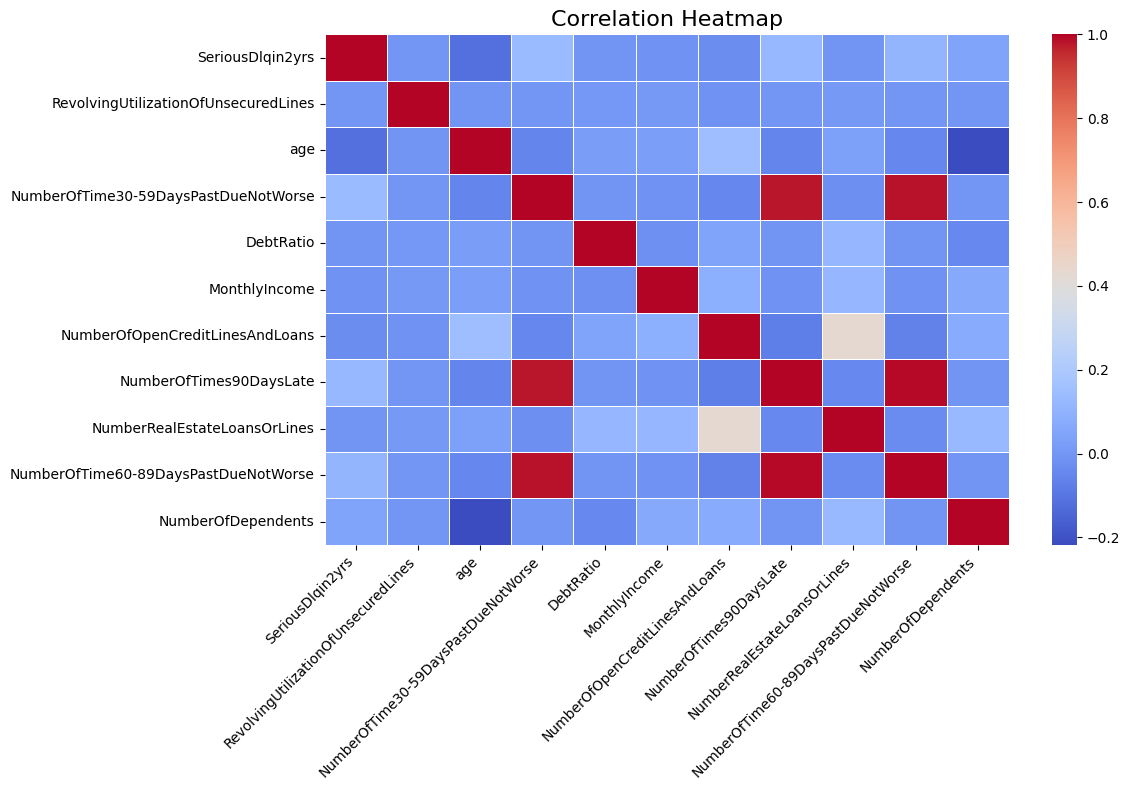

In [88]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, fmt=".2f", cmap="coolwarm",  linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()